In [9]:
# Carga paquetes y ejecución de EDA automatizado para framingham.csv
# Requiere: readr, dplyr, tidyr, purrr, ggplot2, janitor, naniar, GGally, corrplot
library(readr)
library(dplyr)
library(tidyr)
library(purrr)
library(ggplot2)
library(janitor)
library(naniar)
library(GGally)
library(corrplot)

file_path <- "../../data/framingham.csv"
if (!file.exists(file_path)) stop("Archivo framingham.csv no encontrado en el directorio de trabajo.")

df <- readr::read_csv(file_path, show_col_types = FALSE)

# eliminar filas con NA en df
df <- df %>% drop_na()

In [3]:
# Metadatos básicos
dims <- dim(df)
var_types <- tibble(var = names(df), type = purrr::map_chr(df, ~class(.x)[1]))

# Missingness
missing_summary <- tibble(
  var = names(df),
  n_missing = sapply(df, function(x) sum(is.na(x))),
  pct_missing = sapply(df, function(x) mean(is.na(x))) * 100
) %>% arrange(desc(pct_missing))

In [4]:
# Resumen numérico
numeric_vars <- df %>% select(where(is.numeric))
cat_vars <- df %>% select(where(~!is.numeric(.x)))

numeric_summary <- purrr::map_dfr(names(numeric_vars), function(col){
  x <- numeric_vars[[col]]
  tibble(
    var = col,
    n = sum(!is.na(x)),
    mean = mean(x, na.rm = TRUE),
    sd = sd(x, na.rm = TRUE),
    median = median(x, na.rm = TRUE),
    IQR = IQR(x, na.rm = TRUE),
    min = min(x, na.rm = TRUE),
    max = max(x, na.rm = TRUE)
  )
})

In [5]:
# Resumen categórico (top 5 por variable)
categorical_summary <- purrr::map(names(cat_vars), function(col){
  tab <- df %>% count(!!sym(col), name = "n") %>% arrange(desc(n))
  tibble(var = col, top = list(head(tab, 5)))
}) %>% bind_rows()

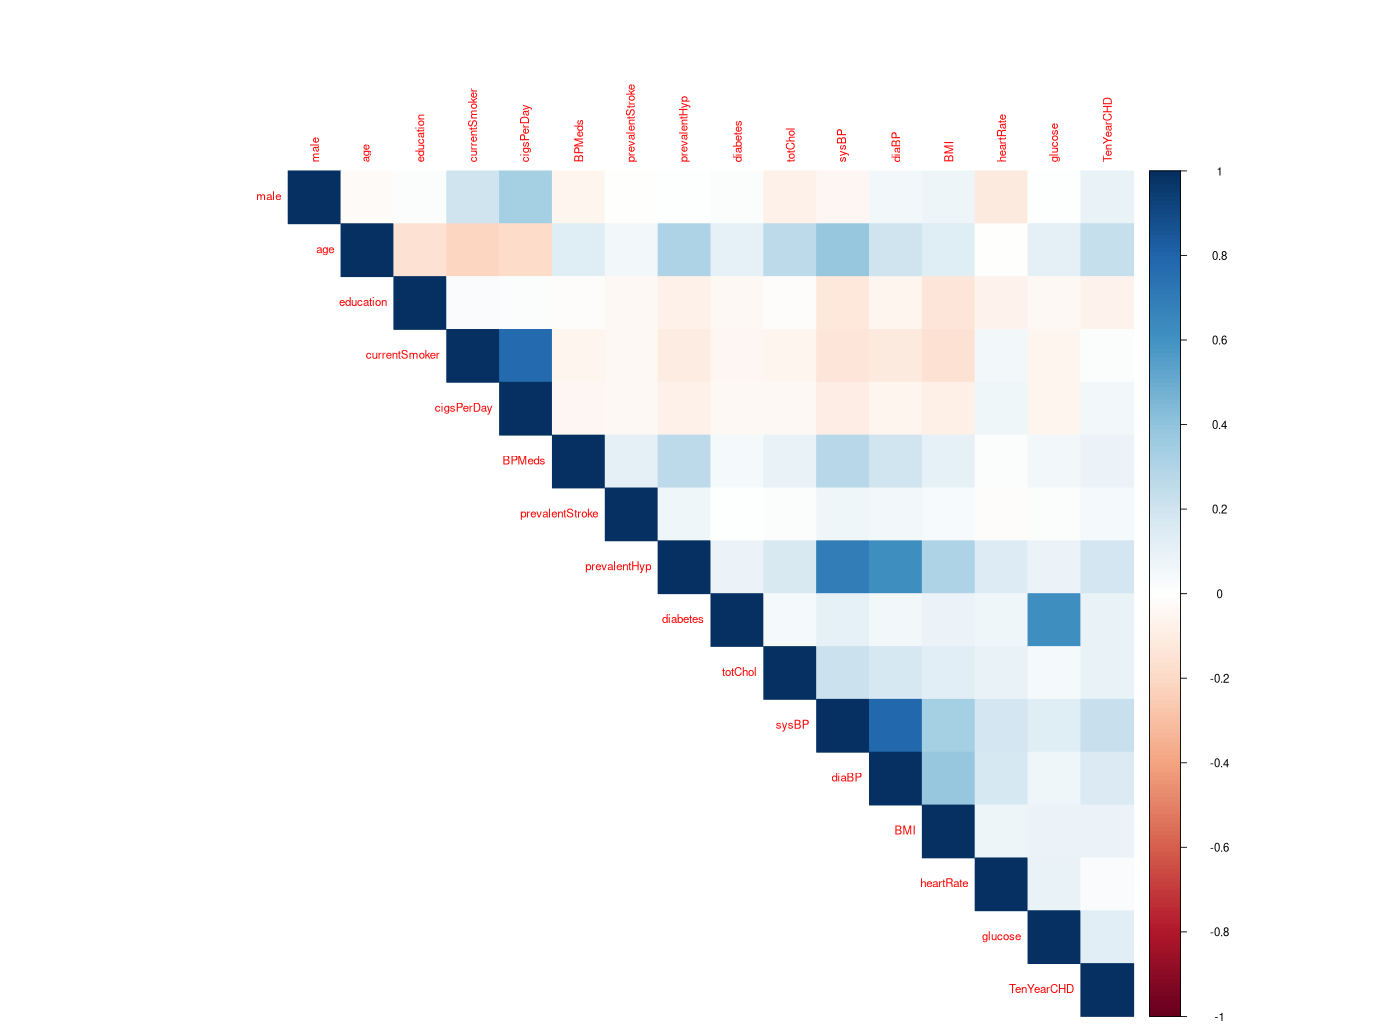

In [6]:
# Correlaciones entre numéricos
cor_matrix <- cor(numeric_vars, use = "pairwise.complete.obs")
corrplot(cor_matrix, method = "color", type = "upper", tl.cex = 0.8)


In [7]:
# Detección de variable objetivo binaria (TenYearCHD u otra 0/1)
outcome_candidates <- names(df)[sapply(df, function(x) {
  is.numeric(x) && length(unique(na.omit(x))) <= 5
})]
outcome <- if ("TenYearCHD" %in% names(df)) "TenYearCHD" else if (length(outcome_candidates)>0) outcome_candidates[1] else NULL


In [8]:
associations <- list()
if (!is.null(outcome)) {
  # asegurar factor para tests si es numérica 0/1
  df[[outcome]] <- factor(df[[outcome]])
  prevalence <- tibble(outcome = outcome, levels = levels(df[[outcome]]), counts = as.integer(table(df[[outcome]])))

  # numéricos vs outcome: t-test (cuando aplicable)
  assoc_num <- purrr::map_dfr(setdiff(names(numeric_vars), outcome), function(col){
    a <- df %>% select(all_of(c(col,outcome))) %>% filter(!is.na(.data[[col]]) & !is.na(.data[[outcome]]))
    res <- tryCatch(t.test(a[[col]] ~ a[[outcome]]), error = function(e) NA)
    tibble(var = col,
           p_value = if (is.list(res)) res$p.value else NA_real_,
           mean_level0 = mean(a[[col]][a[[outcome]]==levels(a[[outcome]])[1]], na.rm = TRUE),
           mean_level1 = mean(a[[col]][a[[outcome]]==levels(a[[outcome]])[2]], na.rm = TRUE))
  })

  # categóricos vs outcome: chisq or fisher
  assoc_cat <- purrr::map_dfr(names(cat_vars), function(col){
    tab <- table(df[[col]], df[[outcome]])
    test <- tryCatch(chisq.test(tab), error = function(e) tryCatch(fisher.test(tab), error = function(e2) NA))
    tibble(var = col, p_value = if (is.list(test)) test$p.value else NA_real_)
  })

  associations <- list(prevalence = prevalence, numeric = assoc_num, categorical = assoc_cat)
}

: [1m[33mError[39m in `df[[outcome]]`:[22m
[33m![39m Can't extract column with `outcome`.
[31m✖[39m Subscript `outcome` must be size 1, not 2.

In [ ]:


# Plots: histograms (numeric), missingness and corrplot, ggpairs sample (up to 8 numeric vars)
plot_list <- list()
if (ncol(numeric_vars) > 0) {
  p_hist <- numeric_vars %>% pivot_longer(everything(), names_to = "var", values_to = "value") %>% 
    ggplot(aes(x = value)) +
    geom_histogram(bins = 30, fill = "#2c7fb8", color = "white") +
    facet_wrap(vars(var), scales = "free") +
    theme_minimal()
  plot_list$histograms <- p_hist
}

if (!is.null(cor_mat)) {
  p_corr <- function(){
    corrplot::corrplot(cor_mat, method = "color", tl.cex = 0.7, number.cex = 0.6)
  }
  plot_list$corrplot <- p_corr
}

plot_list$missing <- naniar::vis_miss(df)

if (ncol(numeric_vars) >= 2) {
  sample_vars <- names(numeric_vars)[1:min(8, ncol(numeric_vars))]
  plot_list$ggpairs <- GGally::ggpairs(df[, sample_vars])
}



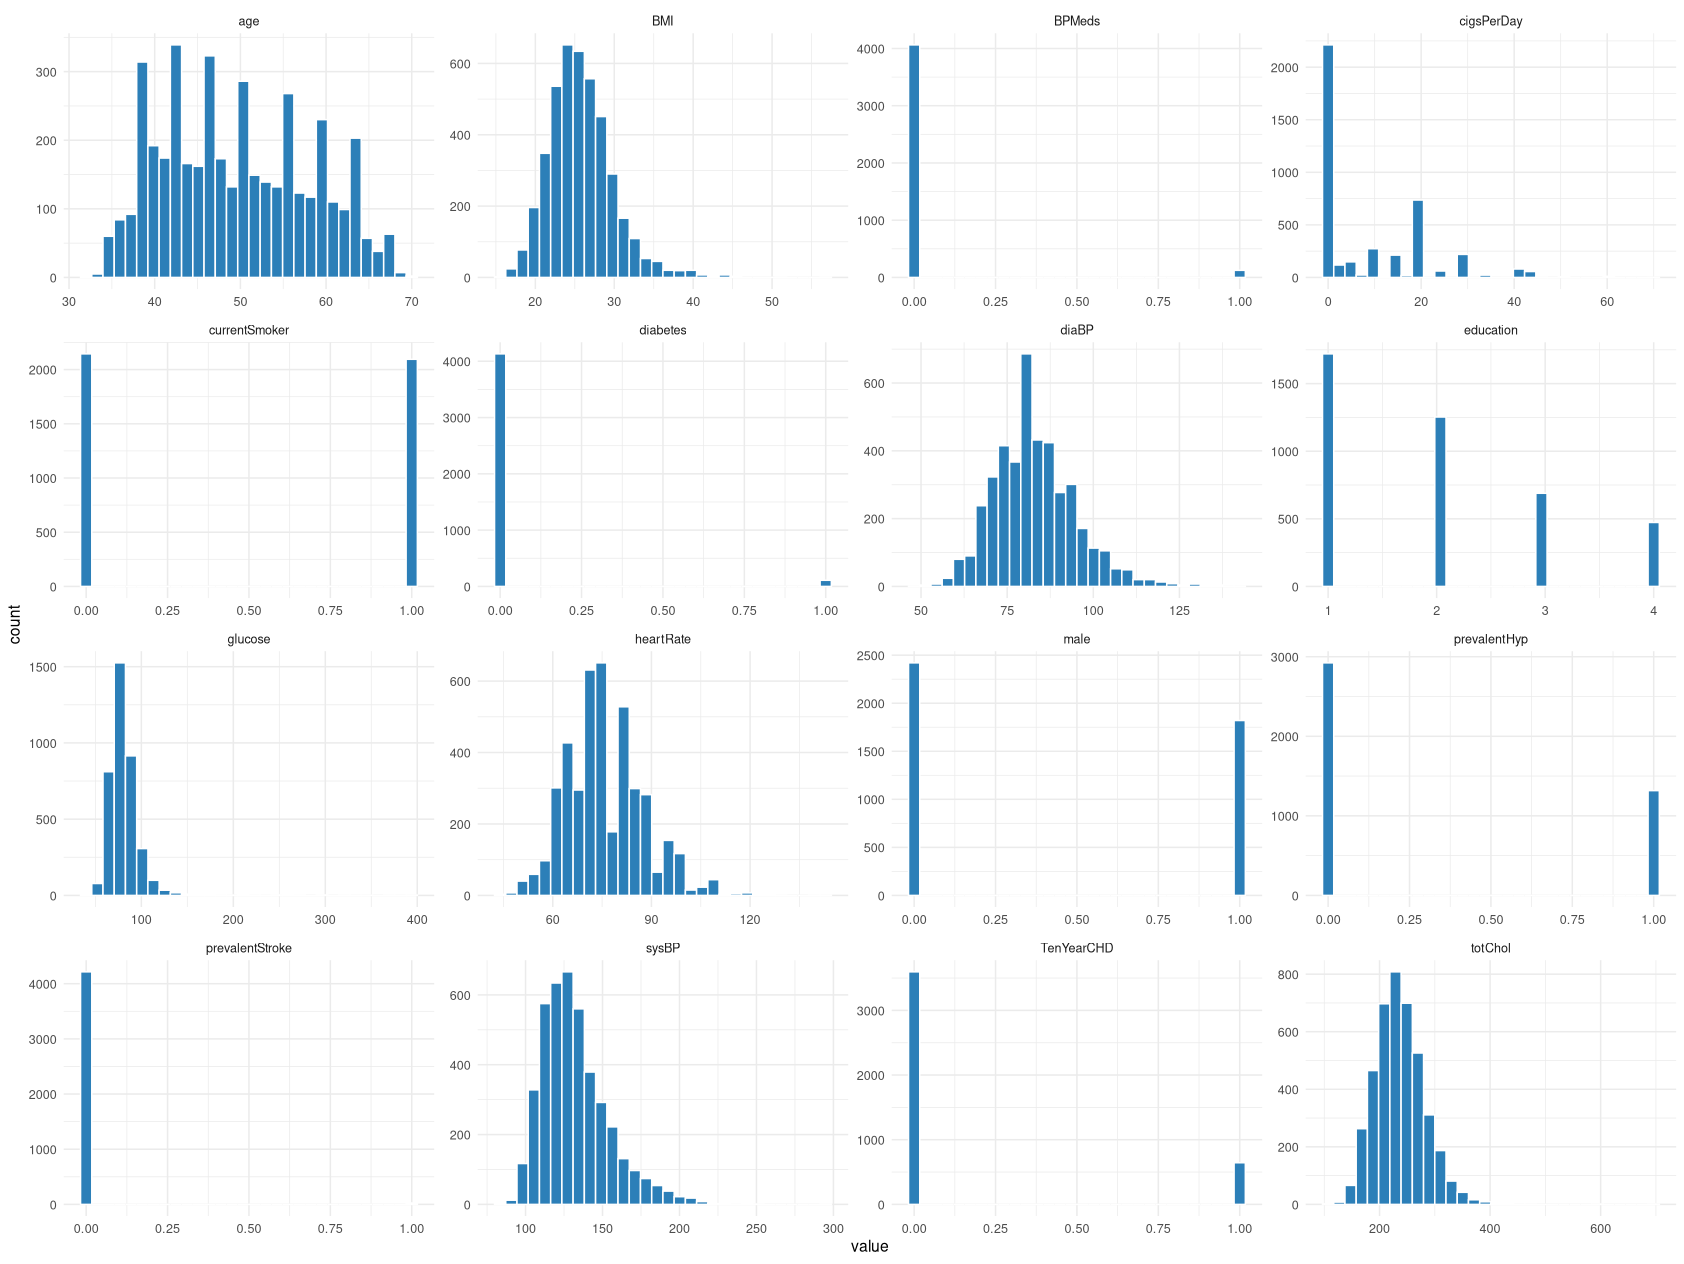

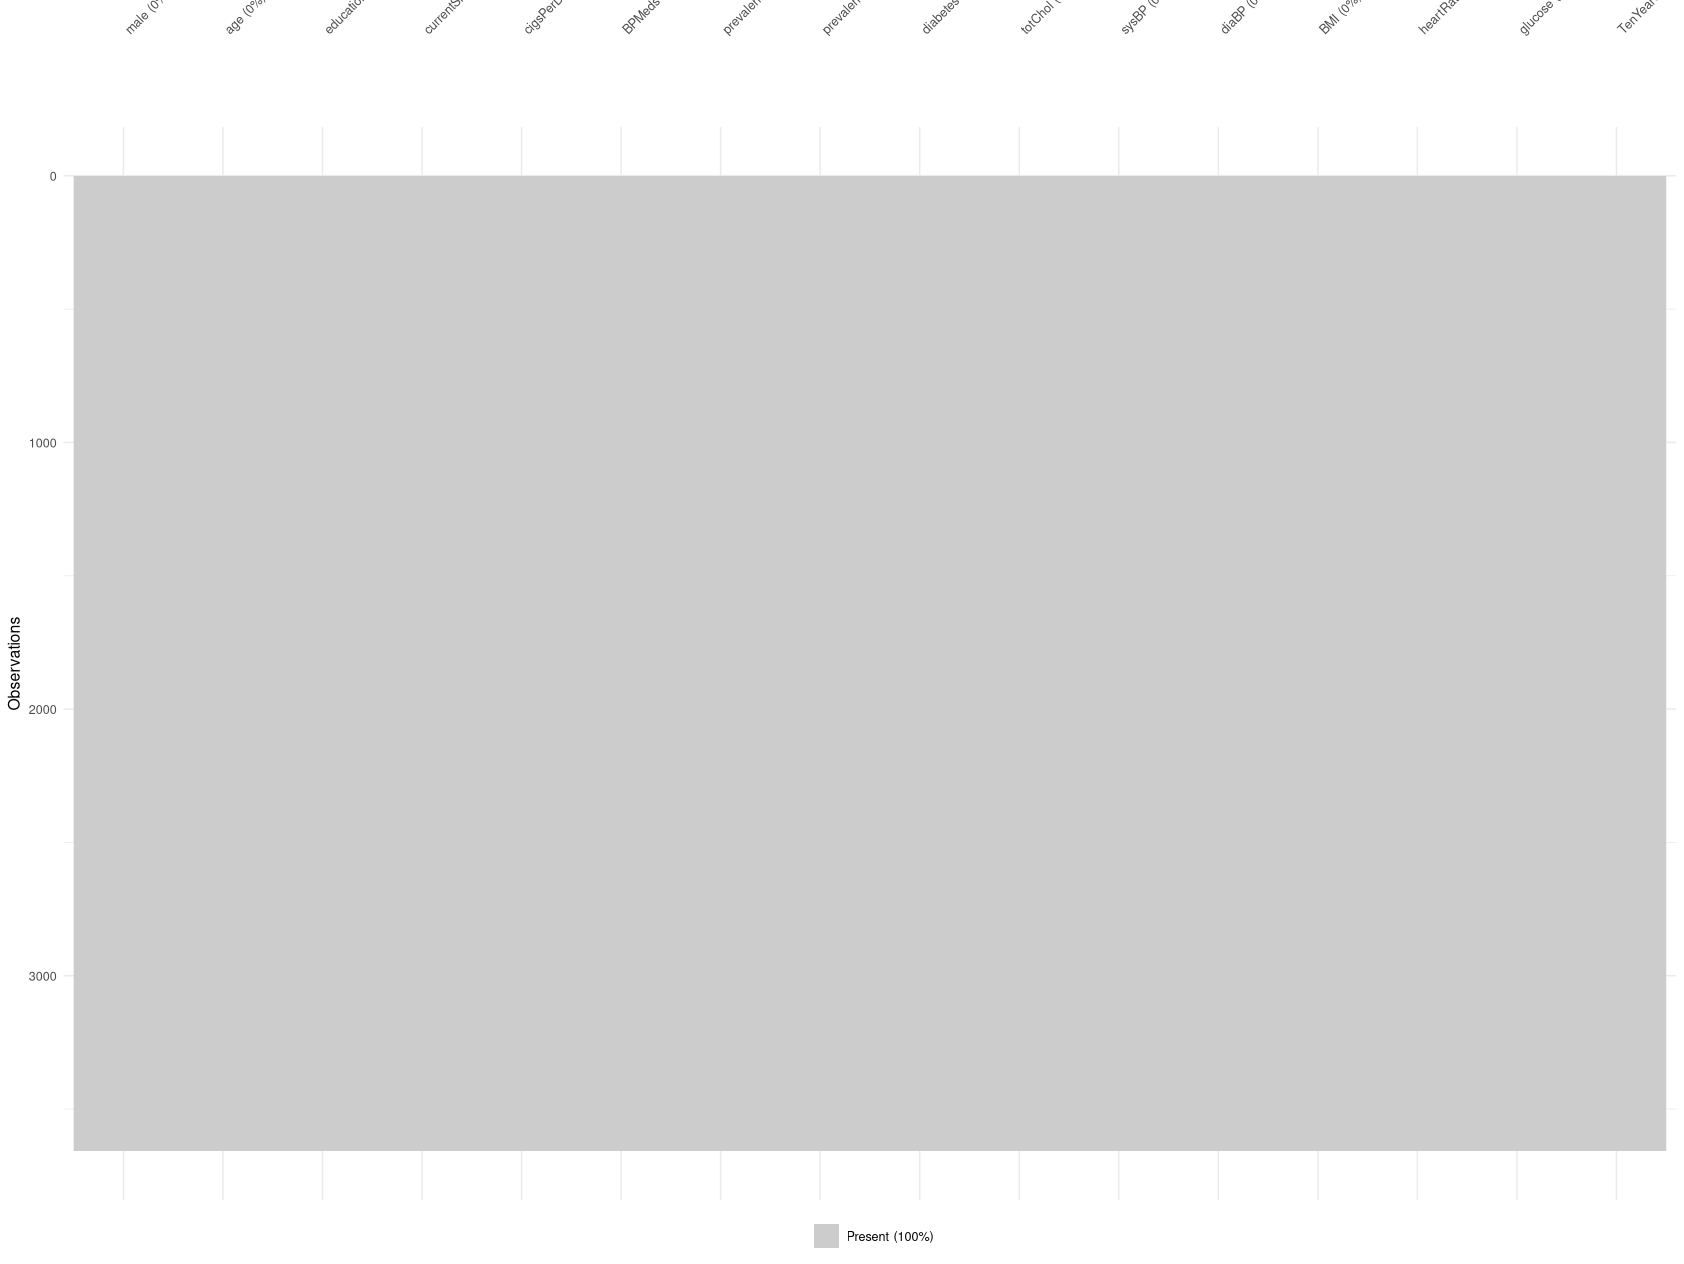

Warning message:
Removed 645 rows containing non-finite outside the scale range (`stat_bin()`). 


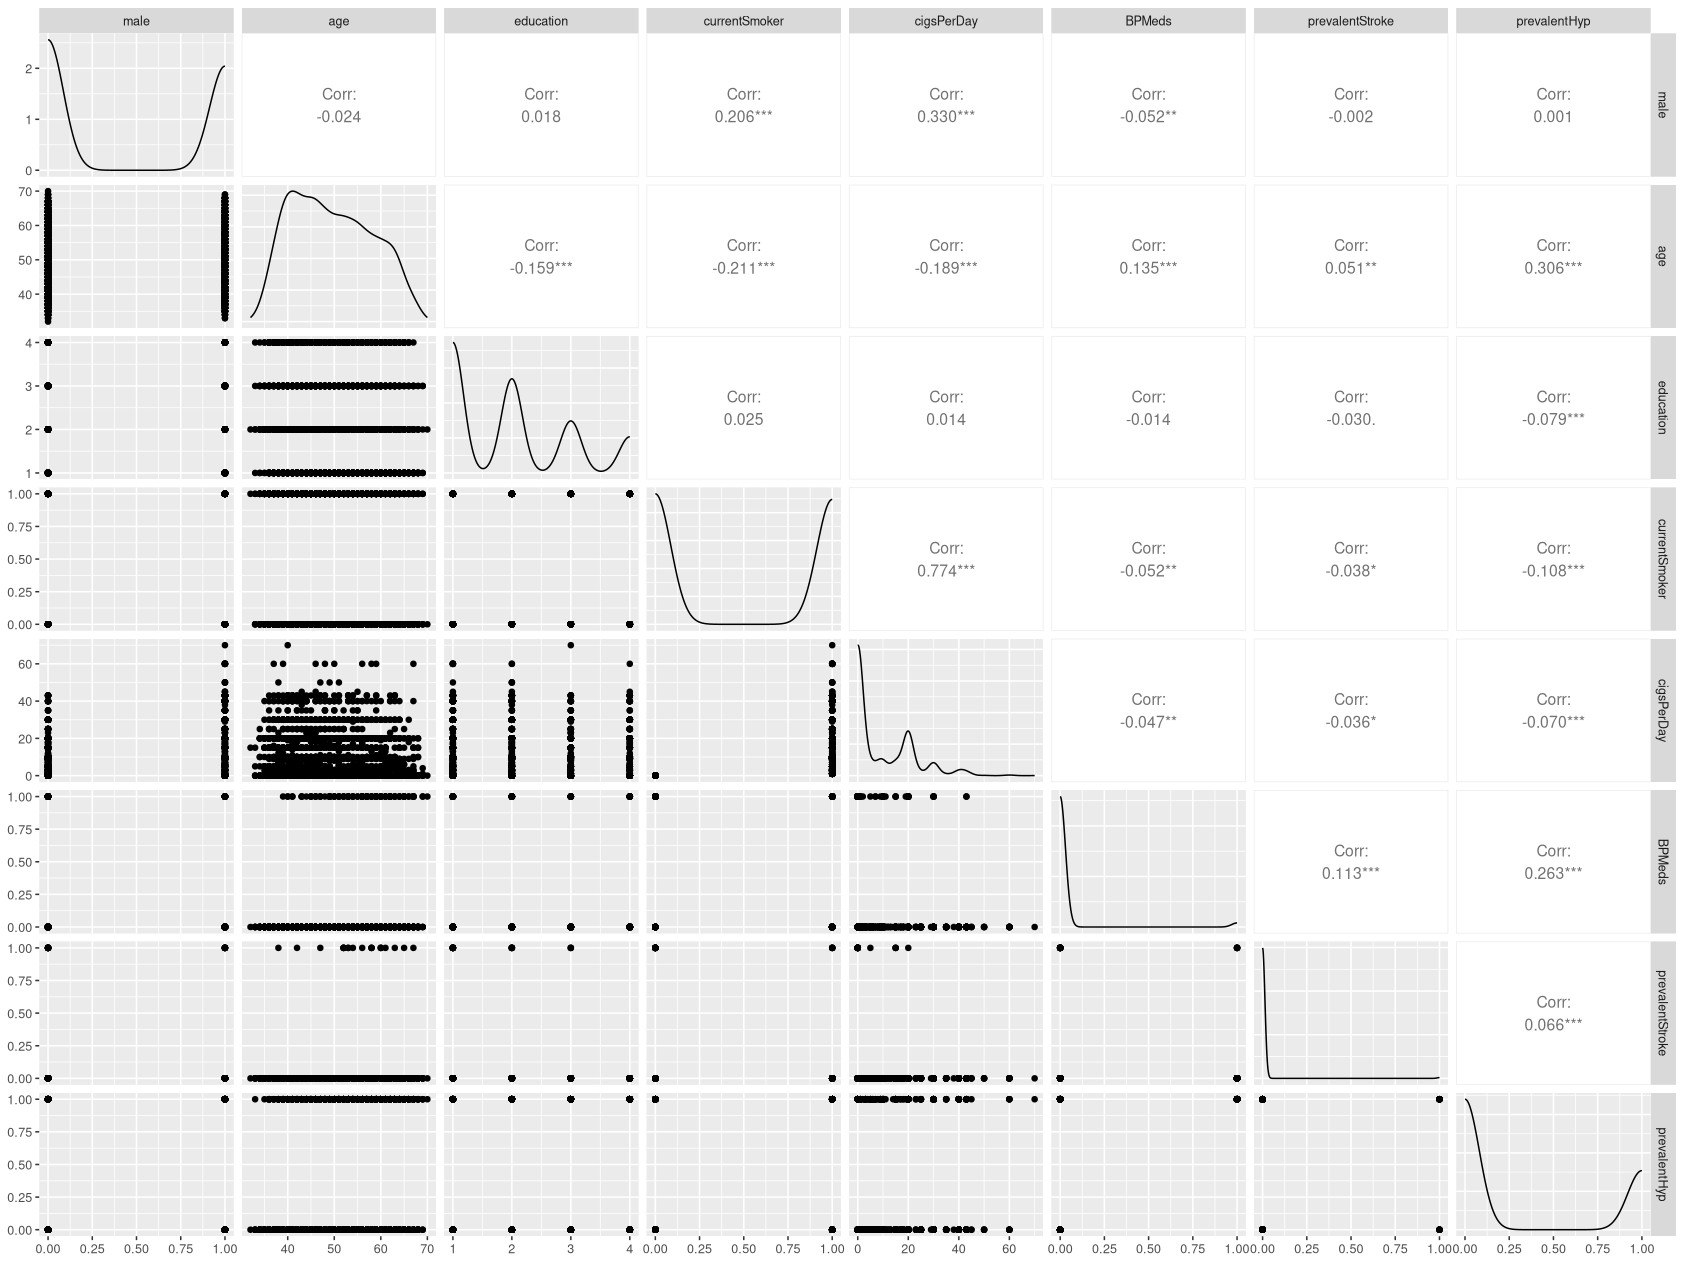

$dims
[1] 4240   16

$var_types
# A tibble: 16 × 2
   var             type   
   <chr>           <chr>  
 1 male            numeric
 2 age             numeric
 3 education       numeric
 4 currentSmoker   numeric
 5 cigsPerDay      numeric
 6 BPMeds          numeric
 7 prevalentStroke numeric
 8 prevalentHyp    numeric
 9 diabetes        numeric
10 totChol         numeric
11 sysBP           numeric
12 diaBP           numeric
13 BMI             numeric
14 heartRate       numeric
15 glucose         numeric
16 TenYearCHD      numeric

$missing_summary
# A tibble: 16 × 3
   var             n_missing pct_missing
   <chr>               <int>       <dbl>
 1 glucose               388      9.15  
 2 education             105      2.48  
 3 BPMeds                 53      1.25  
 4 totChol                50      1.18  
 5 cigsPerDay             29      0.684 
 6 BMI                    19      0.448 
 7 heartRate               1      0.0236
 8 male                    0      0     
 9 age          

In [ ]:
# Resultado final: devolver una lista con objetos útiles
report <- list(
  dims = dims,
  var_types = var_types,
  missing_summary = missing_summary,
  numeric_summary = numeric_summary,
  categorical_summary = categorical_summary,
  cor_mat = cor_mat,
  top_correlations = if (exists("top_corrs")) top_corrs else NULL,
  outcome = outcome,
  associations = associations,
  plots = plot_list
)

report